# Should game publishers care about making players happy?

## 1. Introduction

This analysis is written for **Steam publishers, publishing managers, and product strategy teams** deciding whether investments in player satisfaction are likely to improve business performance. Steam review scores are one of the clearest public signals of **player satisfaction**, but it is not always obvious how much they matter for outcomes that publishers actually care about. Some games reach large scale despite mediocre reviews, while others are well reviewed without becoming major commercial successes. For decision-makers allocating development, live-service, and community-management resources, this raises a practical question: **when does making players happier actually pay off?**

This project uses **Steam store metadata, SteamSpy, IGDB, and Gamealytic publisher data** to examine whether review sentiment is associated with **commercial outcomes** and **engagement outcomes**. Commercial outcomes are measured using ownership and publisher-revenue proxies, while engagement outcomes are measured using playtime, concurrent-player, and retention-style indicators.

The analysis focuses on three questions. First, are stronger review scores associated with stronger commercial outcomes? Second, are review scores more strongly related to engagement than to sales-oriented outcomes? Third, does the value of high review scores differ across **high-revenue and low-revenue publishers**? The goal is to identify **when, and for whom, player satisfaction appears to matter most**.

In [1]:
import requests
import time
import json
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 as sq
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from pprint import pprint

### 2. Data Import

This section imports the four primary datasets used in the analysis: **Steam Store Metadata, SteamSpy, IGDB, and Gamealytic publisher data**. Together, these sources provide review information, store-level game characteristics, engagement and ownership proxies, richer game metadata, and publisher-level commercial context.

- **Steam Store Metadata:** core game-level store and review variables  
- **SteamSpy:** ownership, playtime, and concurrent-player proxies  
- **IGDB:** supplemental game metadata such as genres, themes, and game modes  
- **Gamealytic Publisher Data:** publisher-level revenue and catalog information

### 2.1 Steam Store Metadata

Steam Store metadata serves as the anchor dataset for the analysis. It provides the core game-level fields needed to identify titles, measure review outcomes, and capture store-facing product characteristics such as price, release timing, publisher, developer, and genre information. These fields are later used for filtering, feature construction, and cross-dataset matching.

In [2]:
df_steam = pd.read_csv("steam_master.csv", low_memory=False)
df_steam.head(3)

,steam_id,store_success,store_type,store_name,store_required_age,store_is_free,store_controller_support,store_supported_languages,store_short_description,store_header_image,...,news_count_fetched,news_latest_date,news_latest_date_iso,news_oldest_date,news_oldest_date_iso,news_items_last_30d,news_items_last_90d,news_items_last_365d,news_avg_contents_length,news_feednames
0,10,True,game,Counter-Strike,0,False,NaN,"English<strong>*</strong>, French<strong>*</st...",Play the world's number 1 online action game. ...,https://shared.akamai.steamstatic.com/store_it...,...,100.0,1.768241e+09,2026-01-12T18:01:03+00:00,1.392497e+09,2014-02-15T20:43:52+00:00,0.0,2.0,9.0,3300.310000,"PCGamesN | Rock, Paper, Shotgun | PC Gamer | s..."
1,20,True,game,Team Fortress Classic,0,False,NaN,"English, French, German, Italian, Spanish - Sp...",One of the most popular online action games of...,https://shared.akamai.steamstatic.com/store_it...,...,26.0,1.727885e+09,2024-10-02T15:56:29+00:00,1.314271e+09,2011-08-25T11:15:00+00:00,0.0,0.0,0.0,644.384615,steam_community_announcements | rps | eurogamer
2,30,True,game,Day of Defeat,0,False,NaN,"English, French, German, Italian, Spanish - Spain",Enlist in an intense brand of Axis vs. Allied ...,https://shared.akamai.steamstatic.com/store_it...,...,19.0,1.570558e+09,2019-10-08T18:08:41+00:00,1.278976e+09,2010-07-12T23:12:00+00:00,0.0,0.0,0.0,663.631579,steam_community_announcements | rps | steam_an...


### 2.2 SteamSpy

SteamSpy provides game-level commercial and engagement proxies, including estimated ownership ranges, playtime measures, and concurrent player counts. These variables are especially important for distinguishing between review sentiment and actual player engagement, which is central to this report’s research question.

In [3]:
df_steamspy = pd.read_csv("steamspy_all_raw.csv", low_memory=False)
df_steamspy.head(3)

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",32776,725,6490,327,0.0,0.0,0.0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10521,598,861,258,0.0,0.0,0.0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23282,738,5769,301,0.0,0.0,0.0,314682


### 2.3 IGDB Metadata

The IGDB dataset provides supplemental game-level metadata that helps us describe what each title actually is beyond its store listing. This includes information such as genres, themes, and other classification features. In this project, IGDB is mainly used to control for differences in game type, allowing us to compare review scores and business outcomes more meaningfully across titles.

In [4]:
df_igdb = pd.read_csv("igdb_games.csv", low_memory=False,)
df_igdb.head(3)

,igdb_game_id,igdb_name,igdb_slug,igdb_category,igdb_first_release_date,igdb_first_release_date_iso,igdb_genres,igdb_themes,igdb_game_modes,igdb_player_perspectives,...,igdb_total_rating,igdb_total_rating_count,igdb_hypes,igdb_summary,igdb_storyline,igdb_url,igdb_keywords,igdb_franchises,igdb_collection,igdb_cover_url
0,1,Thief II: The Metal Age,thief-ii-the-metal-age,NaN,9.535968e+08,2000-03-21T00:00:00+00:00,Shooter | Simulator | Adventure,Action | Fantasy | Stealth,Single player,First person,...,88.585229,151.0,NaN,The ultimate thief is back! Tread softly as yo...,The game begins as Garrett continues his life ...,https://www.igdb.com/games/thief-ii-the-metal-age,ghosts | thief | death | swordplay | steampunk...,NaN,NaN,https://images.igdb.com/igdb/image/upload/t_th...
1,3,Thief: Deadly Shadows,thief-deadly-shadows,NaN,1.085443e+09,2004-05-25T00:00:00+00:00,Shooter | Simulator | Adventure,Action | Fantasy | Stealth,Single player,First person | Third person,...,82.421495,131.0,NaN,"In the third instalment of the Thief series, m...",NaN,https://www.igdb.com/games/thief-deadly-shadows,ghosts | assassin | minigames | thief | swordp...,NaN,NaN,https://images.igdb.com/igdb/image/upload/t_th...
2,4,Thief,thief,NaN,1.393286e+09,2014-02-25T00:00:00+00:00,Shooter | Adventure,Action | Stealth | Sandbox,Single player,First person,...,66.771817,343.0,13.0,There is a rising tide of fear in The City. Ha...,"Garrett, the Master Thief, steps out of the sh...",https://www.igdb.com/games/thief,thief | steampunk | blackjack | action-adventu...,NaN,NaN,https://images.igdb.com/igdb/image/upload/t_th...


### 2.4 Publisher Metadata (Gamalytic)

This dataset supplies publisher-level financial and catalog context that is not available in SteamSpy. By incorporating this metadata, the analysis can group games based on their publisher’s observed revenue performance on Steam. This provides a more objective basis for comparison than vague labels such as “AAA” or “indie” alone and supports the later analysis of high-revenue versus low-revenue publishers.

In [5]:
df_publishers = pd.read_csv("Gamealytic_data.csv") 
df_publishers.head(3)

,games,unreleasedGames,name,numberOfGames,firstGameDate,lastGameDate,averageRevenue,medianRevenue,inHouse,class,stats,totalRevenue,genres,id
0,"[{'steamId': 730, 'id': 730, 'name': 'Counter-...","[{'steamId': 1422450, 'id': 1422450, 'name': '...",Valve,29,910501200000,1646110800000,4.951167e+08,2832205.0,86,AAA,"{'numberOfGames': 29, 'totalRevenue': 14260221...",14358384339,"{'Action': 24, 'Free To Play': 7, 'Strategy': ...",Valve
1,"[{'steamId': 578080, 'id': 578080, 'name': 'PU...","[{'steamId': 2686570, 'id': 2686570, 'name': '...","KRAFTON, Inc.",21,1346457600000,1762493514442,2.390674e+08,708088.0,5,AAA,"{'numberOfGames': 21, 'totalRevenue': 50204157...",5020415776,"{'Action': 13, 'Adventure': 7, 'Massively Mult...","KRAFTON, Inc."
2,"[{'steamId': 1172470, 'id': 1172470, 'name': '...","[{'steamId': 2075800, 'id': 2075800, 'name': '...",Electronic Arts,132,1156910400000,1761609600000,3.558370e+07,2837090.5,2,AAA,"{'numberOfGames': 132, 'totalRevenue': 4697048...",4697048174,"{'Action': 80, 'Adventure': 44, 'Free To Play'...",Electronic Arts


### 2.5 SQL Database Import

This project uses **SQLite** to support SQL-based inspection, cleaning, and aggregation alongside the Python workflow. Storing the datasets in a local SQLite database makes it possible to run SQL queries directly on the data while still using pandas for visualization and additional transformations.

At this stage, the four imported datasets are loaded into a SQLite database as tables. The tables are overwritten if they already exist so that the database always reflects the most recent version of the DataFrames used in the notebook.

In [6]:
connection = sq.connect("steam_project.db")
cursor = connection.cursor()

In [7]:
df_steam.to_sql("steam_store", connection, if_exists="replace", index=False)
df_steamspy.to_sql("steamspy", connection, if_exists="replace", index=False)
df_igdb.to_sql("igdb", connection, if_exists="replace", index=False)
df_publishers.to_sql("publishers", connection, if_exists="replace", index=False)

90000

### 3. Data Cleaning and Data Quality Checks

This section checks each dataset for issues that would distort the later analysis, including unstable review labels, non-game records, missing values, inconsistent formats, and fields that require transformation before they can be used in SQL queries, visualizations, and modeling. The goal is to make sure that later comparisons of reviews, engagement, and commercial outcomes are based on valid and interpretable observations.

### 3.1 Steam Store Metadata Cleaning

Before using Steam review tiers in the analysis, SQL is used to inspect all observed values of `review_query_review_score_desc`. This helps identify labels that do not represent stable sentiment categories and should therefore be removed before the main sentiment analysis.

In [8]:
query = """
SELECT review_query_review_score_desc,COUNT(*) AS game_count
FROM steam_store
GROUP BY review_query_review_score_desc
ORDER BY game_count DESC
"""

pd.read_sql_query(query, connection)

,review_query_review_score_desc,game_count
0,No user reviews,48891
1,Very Positive,20435
2,Positive,18903
3,Mixed,17887
4,Mostly Positive,13510
5,1 user reviews,6363
6,2 user reviews,5206
7,3 user reviews,4379
8,4 user reviews,3809
9,5 user reviews,3320


The SQL summary shows that several labels do not represent stable sentiment tiers, including `No user reviews` and the `1 user reviews` through `9 user reviews` categories. These rows are removed so that later review-tier analysis focuses only on meaningful sentiment groups.

In [9]:
df_steam = df_steam[
    (df_steam["review_query_review_score_desc"] != "No user reviews") &
    (df_steam["review_query_review_score_desc"] != "1 user reviews") &
    (df_steam["review_query_review_score_desc"] != "2 user reviews") &
    (df_steam["review_query_review_score_desc"] != "3 user reviews") &
    (df_steam["review_query_review_score_desc"] != "4 user reviews") &
    (df_steam["review_query_review_score_desc"] != "5 user reviews") &
    (df_steam["review_query_review_score_desc"] != "6 user reviews") &
    (df_steam["review_query_review_score_desc"] != "7 user reviews") &
    (df_steam["review_query_review_score_desc"] != "8 user reviews") &
    (df_steam["review_query_review_score_desc"] != "9 user reviews")
].copy()

df_steam.shape

(75288, 76)

The Steam Store table is also checked for the values of `store_type` to confirm that the dataset includes only the kinds of Steam entries relevant to this analysis. Because the focus is on commercial game performance, non-game entries should be excluded before continuing.


In [10]:
query = """
SELECT store_type,COUNT(*) AS game_count
FROM steam_store
GROUP BY store_type
ORDER BY game_count DESC;
"""

pd.read_sql_query(query, connection)

,store_type,game_count
0,game,157465
1,NaN,206
2,mod,1
3,advertising,1


The SQL summary confirms that `store_type` includes multiple types of Steam entries. To keep the sample aligned with the research question, the dataset is filtered to retain only rows where `store_type == "game"`.

In [11]:
df_steam = df_steam[df_steam["store_type"] == "game"].copy()

After removing non-game entries, the Steam Store dataset is restricted to titles that represent actual games. This makes the later comparison of reviews, engagement, and commercial outcomes more consistent across observations.


In [12]:
df_steam["review_query_total_reviews"] = pd.to_numeric(
    df_steam["review_query_total_reviews"], errors="coerce"
)
df_steam.shape

(75125, 76)

After the review-label and store-type filters are applied, key variables are converted to numeric and datetime formats so they can be used consistently in later filtering, aggregation, and visualization steps.


In [13]:
numeric_cols = [
    "store_price_final",
    "store_metacritic_score",
    "store_recommendations_total",
    "review_query_total_reviews",
    "review_query_total_positive",
    "review_query_total_negative",
    "review_query_review_score"
]

for col in numeric_cols:
    df_steam[col] = pd.to_numeric(df_steam[col], errors="coerce")

df_steam["store_release_date"] = pd.to_datetime(
    df_steam["store_release_date_text"], errors="coerce"
)

The retained Steam Store table now contains only game-level observations with stable review-tier labels and the core fields needed for later matching and analysis. Some missingness remains in fields such as publisher names, pricing, and genre labels, but the main review variables are complete after filtering.

In [14]:
steam_keep_cols = [
    "steam_id",
    "store_name",
    "store_is_free",
    "store_release_date_text",
    "store_price_currency",
    "store_price_final",
    "store_developers",
    "store_publishers",
    "store_categories",
    "store_genres",
    "review_query_total_reviews",
    "review_query_total_positive",
    "review_query_total_negative",
    "review_query_review_score",
    "review_query_review_score_desc"
]

df_steam = df_steam[steam_keep_cols].copy()

df_steam.info()

<class 'pandas.DataFrame'>
Index: 75125 entries, 0 to 157026
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   steam_id                        75125 non-null  int64  
 1   store_name                      75124 non-null  str    
 2   store_is_free                   75125 non-null  object 
 3   store_release_date_text         75088 non-null  str    
 4   store_price_currency            60289 non-null  str    
 5   store_price_final               60289 non-null  float64
 6   store_developers                74996 non-null  str    
 7   store_publishers                74644 non-null  str    
 8   store_categories                75118 non-null  str    
 9   store_genres                    75044 non-null  str    
 10  review_query_total_reviews      75125 non-null  int64  
 11  review_query_total_positive     75125 non-null  int64  
 12  review_query_total_negative     75125 non-null 

### 3.2 SteamSpy Cleaning

The SteamSpy dataset is inspected for structural issues before transformation. One notable characteristic is that the `owners` field is stored as a range string rather than a numeric value (for example, `"100,000,000 .. 200,000,000"`). A quick SQL summary is used to inspect how these ranges appear in the dataset before converting them into numeric estimates for analysis.

In [15]:
query = """
SELECT owners, COUNT(*) AS game_count
FROM steamspy
GROUP BY owners
ORDER BY game_count DESC
LIMIT 10
"""

pd.read_sql_query(query, connection)

,owners,game_count
0,"0 .. 20,000",56800
1,"20,000 .. 50,000",11221
2,"50,000 .. 100,000",5540
3,"100,000 .. 200,000",3616
4,"200,000 .. 500,000",3013
5,"500,000 .. 1,000,000",1247
6,"1,000,000 .. 2,000,000",787
7,"2,000,000 .. 5,000,000",432
8,"5,000,000 .. 10,000,000",134
9,"10,000,000 .. 20,000,000",53


Because the `owners` variable is stored as a range rather than a numeric value, the raw ranges are first summarized and then grouped into broad ownership tiers. This preserves their ordering as a rough commercial-scale indicator while a numeric midpoint estimate is created later in the feature-engineering section.

In [16]:
ownership_tiers = {
    "0 .. 20,000": "very_low",
    "20,000 .. 50,000": "very_low",
    "50,000 .. 100,000": "low",
    "100,000 .. 200,000": "low",
    "200,000 .. 500,000": "medium",
    "500,000 .. 1,000,000": "medium",
    "1,000,000 .. 2,000,000": "high",
    "2,000,000 .. 5,000,000": "high",
    "5,000,000 .. 10,000,000": "very_high",
    "10,000,000 .. 20,000,000": "very_high",
    "20,000,000 .. 50,000,000": "blockbuster",
    "50,000,000 .. 100,000,000": "blockbuster",
    "100,000,000 .. 200,000,000": "mega_hit"
}

df_steamspy["owners_tier"] = df_steamspy["owners"].map(ownership_tiers)

df_steamspy[["owners", "owners_tier"]].head()

,owners,owners_tier
0,"100,000,000 .. 200,000,000",mega_hit
1,"100,000,000 .. 200,000,000",mega_hit
2,"100,000,000 .. 200,000,000",mega_hit
3,"50,000,000 .. 100,000,000",blockbuster
4,"50,000,000 .. 100,000,000",blockbuster


### 3.3 IGDB Cleaning

The IGDB dataset is checked for missingness in several key fields before reducing the table. This helps show which metadata are broadly available and which fields are much less complete in the raw dataset.

In [17]:
query = """
SELECT 'Missing genres' AS issue, COUNT(*) AS row_count
FROM igdb
WHERE igdb_genres IS NULL

UNION ALL

SELECT 'Missing game modes' AS issue, COUNT(*) AS row_count
FROM igdb
WHERE igdb_game_modes IS NULL

UNION ALL

SELECT 'Missing total rating' AS issue, COUNT(*) AS row_count
FROM igdb
WHERE igdb_total_rating IS NULL

UNION ALL

SELECT 'Missing release date' AS issue, COUNT(*) AS row_count
FROM igdb
WHERE igdb_first_release_date IS NULL
"""

pd.read_sql_query(query, connection)

,issue,row_count
0,Missing genres,5288
1,Missing game modes,3918
2,Missing total rating,111924
3,Missing release date,24408


The missingness check shows that classification fields such as genres and game modes are relatively well populated, while rating-related fields are much less complete. This suggests that IGDB is more useful here for descriptive game-type controls than for broad rating-based comparisons. The IGDB table is then reduced to the subset of variables needed for matching, genre and mode descriptions, release information, and rating-related fields.

In [18]:
igdb_keep_cols = [
    "igdb_game_id",
    "igdb_name",
    "igdb_slug",
    "igdb_first_release_date",
    "igdb_first_release_date_iso",
    "igdb_genres",
    "igdb_themes",
    "igdb_game_modes",
    "igdb_player_perspectives",
    "igdb_platforms",
    "igdb_developers",
    "igdb_publishers",
    "igdb_rating",
    "igdb_rating_count",
    "igdb_aggregated_rating",
    "igdb_aggregated_rating_count",
    "igdb_total_rating",
    "igdb_total_rating_count",
    "igdb_hypes"
]

df_igdb = df_igdb[igdb_keep_cols].copy()
df_igdb.head(3)

,igdb_game_id,igdb_name,igdb_slug,igdb_first_release_date,igdb_first_release_date_iso,igdb_genres,igdb_themes,igdb_game_modes,igdb_player_perspectives,igdb_platforms,igdb_developers,igdb_publishers,igdb_rating,igdb_rating_count,igdb_aggregated_rating,igdb_aggregated_rating_count,igdb_total_rating,igdb_total_rating_count,igdb_hypes
0,1,Thief II: The Metal Age,thief-ii-the-metal-age,9.535968e+08,2000-03-21T00:00:00+00:00,Shooter | Simulator | Adventure,Action | Fantasy | Stealth,Single player,First person,PC (Microsoft Windows),Looking Glass Studios,Eidos Interactive | Square Enix | Eidos Montréal,87.170459,150.0,90.000000,1.0,88.585229,151.0,NaN
1,3,Thief: Deadly Shadows,thief-deadly-shadows,1.085443e+09,2004-05-25T00:00:00+00:00,Shooter | Simulator | Adventure,Action | Fantasy | Stealth,Single player,First person | Third person,Xbox | PC (Microsoft Windows),Ion Storm,Eidos Interactive | Square Enix | Eidos Montréal,81.842990,129.0,83.000000,2.0,82.421495,131.0,NaN
2,4,Thief,thief,1.393286e+09,2014-02-25T00:00:00+00:00,Shooter | Adventure,Action | Stealth | Sandbox,Single player,First person,PlayStation 3 | PlayStation 4 | PC (Microsoft ...,Eidos Montréal,Square Enix | Feral Interactive | Eidos Montréal,69.900777,329.0,63.642857,14.0,66.771817,343.0,13.0


The retained IGDB fields are then standardized so that release information and rating variables can be used consistently in later matching and analysis.

In [19]:
igdb_numeric_cols = [
    "igdb_first_release_date",
    "igdb_rating",
    "igdb_rating_count",
    "igdb_aggregated_rating",
    "igdb_aggregated_rating_count",
    "igdb_total_rating",
    "igdb_total_rating_count",
    "igdb_hypes"
]

for col in igdb_numeric_cols:
    df_igdb[col] = pd.to_numeric(df_igdb[col], errors="coerce")

df_igdb["igdb_release_date"] = pd.to_datetime(
    df_igdb["igdb_first_release_date_iso"], errors="coerce"
)

df_igdb["igdb_release_year"] = df_igdb["igdb_release_date"].dt.year

df_igdb.info()

<class 'pandas.DataFrame'>
RangeIndex: 131558 entries, 0 to 131557
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype              
---  ------                        --------------   -----              
 0   igdb_game_id                  131558 non-null  int64              
 1   igdb_name                     131558 non-null  str                
 2   igdb_slug                     131558 non-null  str                
 3   igdb_first_release_date       107150 non-null  float64            
 4   igdb_first_release_date_iso   107150 non-null  str                
 5   igdb_genres                   126270 non-null  str                
 6   igdb_themes                   83899 non-null   str                
 7   igdb_game_modes               127640 non-null  str                
 8   igdb_player_perspectives      47018 non-null   str                
 9   igdb_platforms                119896 non-null  str                
 10  igdb_developers               5

### 3.4 Publisher Data Cleaning

 A standardized publisher key is then created to improve matching across datasets. The key removes case differences, spaces, and punctuation so that minor formatting differences are less likely to break joins. 

In [20]:
df_publishers = df_publishers.reset_index(drop=True).copy()
df_publishers["publisher_row_id"] = df_publishers.index + 1

A standardized publisher-name key is also created to support consistency checks and possible name-based comparisons across datasets. However, because the Gamealytic data includes nested game lists, the main game-to-publisher mapping later relies on Steam app IDs extracted from those nested records rather than on publisher-name matching alone.

In [21]:
df_publishers["publisher_name_key"] = (
    df_publishers["name"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "", regex=True)
    .str.replace(r"[^a-z0-9]", "", regex=True)
)

df_publishers.head(3)

,games,unreleasedGames,name,numberOfGames,firstGameDate,lastGameDate,averageRevenue,medianRevenue,inHouse,class,stats,totalRevenue,genres,id,publisher_row_id,publisher_name_key
0,"[{'steamId': 730, 'id': 730, 'name': 'Counter-...","[{'steamId': 1422450, 'id': 1422450, 'name': '...",Valve,29,910501200000,1646110800000,4.951167e+08,2832205.0,86,AAA,"{'numberOfGames': 29, 'totalRevenue': 14260221...",14358384339,"{'Action': 24, 'Free To Play': 7, 'Strategy': ...",Valve,1,valve
1,"[{'steamId': 578080, 'id': 578080, 'name': 'PU...","[{'steamId': 2686570, 'id': 2686570, 'name': '...","KRAFTON, Inc.",21,1346457600000,1762493514442,2.390674e+08,708088.0,5,AAA,"{'numberOfGames': 21, 'totalRevenue': 50204157...",5020415776,"{'Action': 13, 'Adventure': 7, 'Massively Mult...","KRAFTON, Inc.",2,kraftoninc
2,"[{'steamId': 1172470, 'id': 1172470, 'name': '...","[{'steamId': 2075800, 'id': 2075800, 'name': '...",Electronic Arts,132,1156910400000,1761609600000,3.558370e+07,2837090.5,2,AAA,"{'numberOfGames': 132, 'totalRevenue': 4697048...",4697048174,"{'Action': 80, 'Adventure': 44, 'Free To Play'...",Electronic Arts,3,electronicarts


The cleaned publisher table retains the financial and catalog fields needed for later publisher-tier analysis while preserving the nested game lists required to map publisher revenue back to individual Steam titles.

In [22]:
publishers_keep_cols = [
        "publisher_row_id",
        "games",
        "name",
        "numberOfGames",
        "firstGameDate",
        "lastGameDate",
        "averageRevenue",
        "medianRevenue",
        "inHouse",
        "class",
        "stats",
        "totalRevenue",
        "genres",
        "publisher_name_key"
]


df_publishers = df_publishers[publishers_keep_cols].copy()
df_publishers.info()

<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   publisher_row_id    90000 non-null  int64  
 1   games               90000 non-null  str    
 2   name                90000 non-null  str    
 3   numberOfGames       90000 non-null  int64  
 4   firstGameDate       90000 non-null  int64  
 5   lastGameDate        90000 non-null  int64  
 6   averageRevenue      90000 non-null  float64
 7   medianRevenue       90000 non-null  float64
 8   inHouse             90000 non-null  int64  
 9   class               90000 non-null  str    
 10  stats               90000 non-null  str    
 11  totalRevenue        90000 non-null  int64  
 12  genres              90000 non-null  str    
 13  publisher_name_key  90000 non-null  str    
dtypes: float64(2), int64(6), str(6)
memory usage: 483.6 MB


### 3.5 Updating SQL

Because several cleaned and engineered variables were added after the initial database import, the SQLite tables are refreshed here so that later SQL queries use the most current versions of the datasets.

In [23]:
df_steam.to_sql("steam_store", connection, if_exists="replace", index=False)
df_steamspy.to_sql("steamspy", connection, if_exists="replace", index=False)
df_igdb.to_sql("igdb", connection, if_exists="replace", index=False)
df_publishers.to_sql("publishers", connection, if_exists="replace", index=False)

90000

### 4. Feature Engineering and EDA

This section converts the cleaned raw data into analysis-ready features and then uses those features to examine baseline relationships in the sample. The engineered variables focus on three ideas central to the project: **commercial scale**, **engagement intensity**, and **publisher type**. These features are then used to test whether stronger review sentiment is associated with stronger business outcomes.

### 4.1 Feature Engineering

This section creates the derived variables used in the main analysis. These features convert raw platform and publisher fields into more interpretable measures of commercial scale, engagement intensity, and publisher revenue grouping.

Because SteamSpy reports ownership as a range rather than a single numeric value, a midpoint estimate is created to approximate each game’s ownership level. This produces a usable commercial-scale proxy for later comparisons of review sentiment and market performance.

In [24]:
owners_split = df_steamspy["owners"].str.split(" .. ", expand=True)

df_steamspy["owners_low"] = (
    owners_split[0].str.replace(",", "", regex=False).astype(float)
)

df_steamspy["owners_high"] = (
    owners_split[1].str.replace(",", "", regex=False).astype(float)
)

df_steamspy["owners_est"] = (
    df_steamspy["owners_low"] + df_steamspy["owners_high"]
) / 2

df_steamspy[["owners", "owners_low", "owners_high", "owners_est"]].head()

,owners,owners_low,owners_high,owners_est
0,"100,000,000 .. 200,000,000",100000000.0,200000000.0,150000000.0
1,"100,000,000 .. 200,000,000",100000000.0,200000000.0,150000000.0
2,"100,000,000 .. 200,000,000",100000000.0,200000000.0,150000000.0
3,"50,000,000 .. 100,000,000",50000000.0,100000000.0,75000000.0
4,"50,000,000 .. 100,000,000",50000000.0,100000000.0,75000000.0


A stickiness measure is also created to capture engagement intensity. It is defined as concurrent players divided by estimated owners, which gives a rough sense of how active a game’s player base is relative to its overall scale.

In [25]:
df_steamspy["stickiness_pct"] = (
    df_steamspy["ccu"] / df_steamspy["owners_est"]
) * 100

df_steamspy[["owners_est", "ccu", "stickiness_pct"]].head()

,owners_est,ccu,stickiness_pct
0,150000000.0,1013936,0.675957
1,150000000.0,124262,0.082841
2,150000000.0,314682,0.209788
3,75000000.0,18028,0.024037
4,75000000.0,43819,0.058425


A broader publisher-tier grouping is also created from the detailed publisher class labels. This simplifies later comparisons by collapsing the original categories into a higher-revenue versus lower-revenue split that is easier to interpret in the baseline analysis.

In [26]:
publisher_tier_map = {
    "AAA": "High Revenue",
    "AA": "High Revenue",
    "A": "Low Revenue",
    "Indie": "Low Revenue"
}

df_publishers["publisher_tier"] = df_publishers["class"].map(publisher_tier_map)

df_publishers[["class", "publisher_tier"]].head()

,class,publisher_tier
0,AAA,High Revenue
1,AAA,High Revenue
2,AAA,High Revenue
3,AAA,High Revenue
4,AAA,High Revenue


A standardized publisher-name key is also created in the Steam Store data to support consistency checks and possible supplementary joins. However, the main publisher-to-game mapping later relies on Steam app IDs extracted from the nested publisher game lists rather than on publisher-name matching alone.

In [27]:
df_steam["publisher_name_key"] = (
    df_steam["store_publishers"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "", regex=True)
    .str.replace(r"[^a-z0-9]", "", regex=True)
)

df_steam[["store_publishers", "publisher_name_key"]].head()

,store_publishers,publisher_name_key
0,Valve,valve
1,Valve,valve
2,Valve,valve
3,Valve,valve
4,Valve,valve


Because the Gamealytic dataset is organized at the publisher level, with each publisher row containing a nested list of its games, publisher revenue should be assigned to Steam titles through the nested `games` field rather than by publisher-name matching alone. The next step extracts Steam app IDs from those nested lists to build a cleaner game-to-publisher mapping table.

In [28]:
rows = []

for i in range(len(df_publishers)):
    games_list = eval(df_publishers.loc[i, "games"])
    
    for game in games_list:
        rows.append([
            game["steamId"],
            df_publishers.loc[i, "name"],
            df_publishers.loc[i, "class"],
            df_publishers.loc[i, "publisher_tier"],
            df_publishers.loc[i, "totalRevenue"]
        ])

df_publisher_games = pd.DataFrame(
    rows,
    columns=[
        "steam_id",
        "publisher_name",
        "publisher_class",
        "publisher_tier",
        "publisher_total_revenue"
    ]
)

df_publisher_games.head()

,steam_id,publisher_name,publisher_class,publisher_tier,publisher_total_revenue
0,730,Valve,AAA,High Revenue,14358384339
1,570,Valve,AAA,High Revenue,14358384339
2,550,Valve,AAA,High Revenue,14358384339
3,440,Valve,AAA,High Revenue,14358384339
4,4000,Valve,AAA,High Revenue,14358384339


The resulting bridge table converts publisher-level records into a game-level mapping that can later be merged onto Steam titles by `steam_id`. This makes it possible to compare game reviews with publisher revenue grouping in a much cleaner way than direct name-based matching. The initial bridge table is then checked for duplicate Steam app IDs. Because the Gamealytic publisher records contain repeated game mappings, the raw bridge table is not one row per game. To make the later merge valid, the bridge is reduced to a single row per `steam_id` before being used in the analysis.

In [29]:
df_publisher_games["steam_id"].duplicated().sum()

np.int64(1151733)

In [30]:
duplicate_steam_ids = (
    df_publisher_games["steam_id"]
    .value_counts()
    .reset_index()
)

duplicate_steam_ids.columns = ["steam_id", "count"]

duplicate_steam_ids[duplicate_steam_ids["count"] > 1].head(20)

,steam_id,count
0,32370,360
1,368340,360
2,1105670,360
3,1084600,360
4,1732180,270
5,2864560,270
6,1167450,270
7,1778290,270
8,1820050,270
9,1997420,270


In [31]:
df_publisher_games = df_publisher_games.drop_duplicates(subset=["steam_id"]).copy()

df_publisher_games["steam_id"].duplicated().sum()

np.int64(0)

To improve cross-dataset title matching, a standardized `title_key` is created in both the Steam and IGDB data by lowercasing titles and removing spaces and punctuation. This provides a cleaner basis for later title-based joins than relying on raw game names alone.

In [32]:
df_steam["title_key"] = (
    df_steam["store_name"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "", regex=True)
    .str.replace(r"[^a-z0-9]", "", regex=True)
)

df_igdb["title_key"] = (
    df_igdb["igdb_name"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "", regex=True)
    .str.replace(r"[^a-z0-9]", "", regex=True)
)

df_steam[["store_name", "title_key"]].head()

,store_name,title_key
0,Counter-Strike,counterstrike
1,Team Fortress Classic,teamfortressclassic
2,Day of Defeat,dayofdefeat
3,Deathmatch Classic,deathmatchclassic
4,Half-Life: Opposing Force,halflifeopposingforce


Since new engineered variables were added after the last database refresh, the SQLite tables are updated again here so that the SQL queries in the EDA section use the most recent versions of the cleaned and feature-engineered datasets.

In [33]:
df_steam.to_sql("steam_store", connection, if_exists="replace", index=False)
df_steamspy.to_sql("steamspy", connection, if_exists="replace", index=False)
df_igdb.to_sql("igdb", connection, if_exists="replace", index=False)
df_publishers.to_sql("publishers", connection, if_exists="replace", index=False)
df_publisher_games.to_sql("publisher_games", connection, if_exists="replace", index=False)

11787

### 4.2 Baseline EDA

The baseline EDA begins by examining how review sentiment is distributed across the cleaned Steam sample. It then compares review tiers to a commercial-scale proxy to see whether stronger player sentiment is associated with larger typical game outcomes before moving to engagement and publisher-level comparisons later in the analysis.

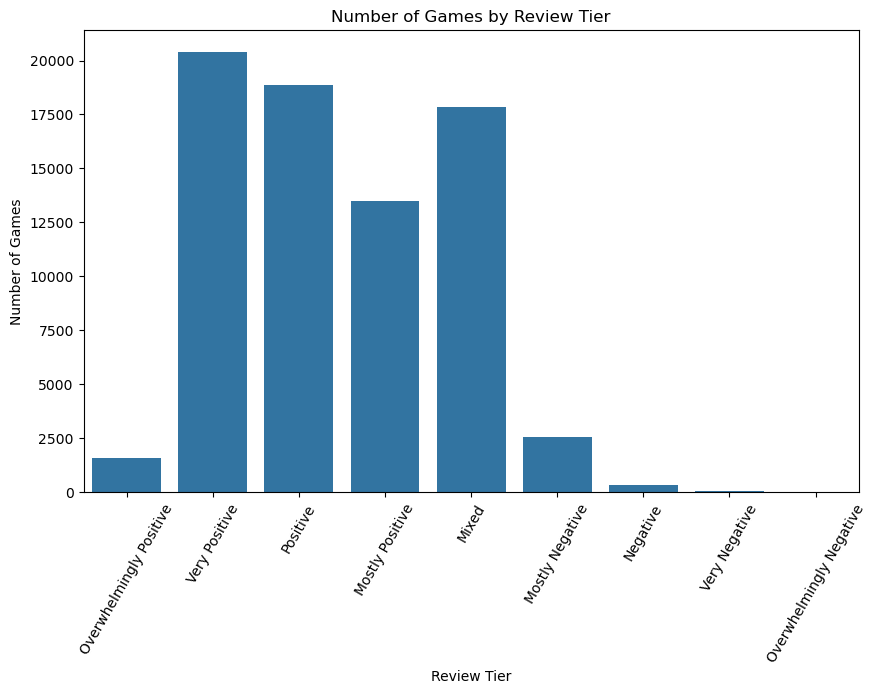

In [34]:
review_order = [
    "Overwhelmingly Positive",
    "Very Positive",
    "Positive",
    "Mostly Positive",
    "Mixed",
    "Mostly Negative",
    "Negative",
    "Very Negative",
    "Overwhelmingly Negative"
]

review_tier_counts = (
    df_steam["review_query_review_score_desc"]
    .value_counts()
    .reindex(review_order, fill_value=0)
    .reset_index()
)

review_tier_counts.columns = ["review_tier", "game_count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=review_tier_counts, x="review_tier", y="game_count")

plt.title("Number of Games by Review Tier")
plt.xlabel("Review Tier")
plt.ylabel("Number of Games")
plt.xticks(rotation=60)
plt.show()

The distribution shows that most retained games fall into positive or mixed review categories, while the strongly negative tiers are relatively rare. This suggests that the Steam market is not dominated by poorly reviewed games, but it does not yet show whether more favorable review sentiment is associated with stronger business outcomes.

To connect review sentiment with publisher-level business outcomes, the next step uses SQL to join the cleaned Steam Store table to the deduplicated game-to-publisher bridge table on `steam_id`. This creates a game-level view that links each title’s review tier to its publisher’s revenue grouping and total publisher revenue.

In [35]:
query = """

SELECT s.steam_id, s.store_name, s.review_query_review_score_desc, p.publisher_name, p.publisher_tier, p.publisher_total_revenue
FROM steam_store AS s
INNER JOIN publisher_games AS p 
ON s.steam_id = p.steam_id

"""

df_review_pub = pd.read_sql_query(query, connection)

df_review_pub.head()

,steam_id,store_name,review_query_review_score_desc,publisher_name,publisher_tier,publisher_total_revenue
0,10,Counter-Strike,Overwhelmingly Positive,Valve,High Revenue,14358384339
1,20,Team Fortress Classic,Very Positive,Valve,High Revenue,14358384339
2,30,Day of Defeat,Very Positive,Valve,High Revenue,14358384339
3,40,Deathmatch Classic,Very Positive,Valve,High Revenue,14358384339
4,50,Half-Life: Opposing Force,Overwhelmingly Positive,Valve,High Revenue,14358384339


With the game-level review and publisher data now linked, the next step is to summarize how review tiers are distributed across high-revenue and low-revenue publishers. This provides a first descriptive check of whether stronger publishers tend to have a different review profile from the rest of the sample.

In [36]:
query = """

SELECT
    publisher_tier,
    review_query_review_score_desc,
    COUNT(*) AS game_count
FROM (
    SELECT
        s.steam_id,
        s.review_query_review_score_desc,
        p.publisher_tier
    FROM steam_store AS s
    INNER JOIN publisher_games AS p
        ON s.steam_id = p.steam_id
)
GROUP BY publisher_tier, review_query_review_score_desc
ORDER BY publisher_tier, game_count DESC

"""

review_pub_counts = pd.read_sql_query(query, connection)

review_pub_counts

,publisher_tier,review_query_review_score_desc,game_count
0,High Revenue,Very Positive,2292
1,High Revenue,Mostly Positive,1112
2,High Revenue,Mixed,1033
3,High Revenue,Overwhelmingly Positive,272
4,High Revenue,Positive,98
5,High Revenue,Mostly Negative,92
6,High Revenue,Very Negative,3
7,High Revenue,Overwhelmingly Negative,3
8,High Revenue,Negative,1
9,Low Revenue,Very Positive,3006


Because the high-revenue and low-revenue publisher groups contain different numbers of games, raw counts are not directly comparable. The next step converts the SQL summary into within-group proportions so that the review-tier distribution can be compared more meaningfully across publisher tiers.

In [37]:
review_pub_table = review_pub_counts.pivot(
    index="publisher_tier",
    columns="review_query_review_score_desc",
    values="game_count"
).fillna(0)

review_pub_table = review_pub_table.reindex(columns=review_order, fill_value=0)

review_pub_props = review_pub_table.div(
    review_pub_table.sum(axis=1),
    axis=0
)

review_pub_props

review_query_review_score_desc,Overwhelmingly Positive,Very Positive,Positive,Mostly Positive,Mixed,Mostly Negative,Negative,Very Negative,Overwhelmingly Negative
publisher_tier,,,,,,,,,
High Revenue,0.055442,0.467183,0.019976,0.226661,0.210558,0.018753,0.000204,0.000611,0.000611
Low Revenue,0.062385,0.459633,0.063609,0.196024,0.196942,0.018960,0.001070,0.000765,0.000612


To make the publisher-tier comparison easier to interpret, the within-group proportions are plotted as a stacked bar chart. This shows whether high-revenue and low-revenue publishers have noticeably different review-tier profiles after accounting for the fact that the two groups contain different numbers of games.

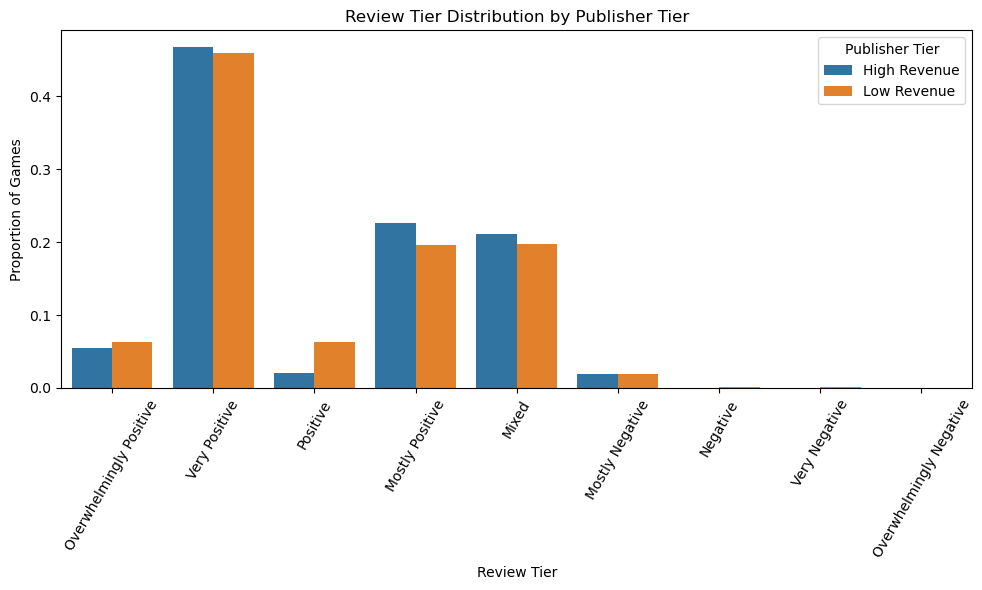

In [38]:
review_pub_props_long = review_pub_props.reset_index().melt(
    id_vars="publisher_tier",
    var_name="review_tier",
    value_name="proportion"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=review_pub_props_long,
    x="review_tier",
    y="proportion",
    hue="publisher_tier"
)

plt.title("Review Tier Distribution by Publisher Tier")
plt.xlabel("Review Tier")
plt.ylabel("Proportion of Games")
plt.xticks(rotation=60)
plt.legend(title="Publisher Tier")
plt.tight_layout()

plt.show()

The review distributions for high-revenue and low-revenue publishers appear very similar. Both groups are dominated by "Very Positive", "Mostly Positive", and "Mixed" titles, while strongly negative review tiers are rare in both groups.

This suggests that review sentiment alone does not clearly separate commercially successful publishers from the rest of the market. High-revenue publishers do not simply succeed because all of their games receive dramatically better reviews.

Because review sentiment does not appear to explain publisher-level commercial outcomes by itself, the next step is to explore whether other factors—such as player engagement or specific game types—help explain why some games remain commercially successful despite weaker reviews.

To provide additional context on publisher-level commercial scale, the next query ranks matched publishers by total revenue using a SQL window function. This helps show how concentrated publisher revenue is in the sample and reinforces why publisher scale may reflect structural advantages beyond review sentiment alone.

In [39]:
query = """

SELECT publisher_name, publisher_class, publisher_tier, publisher_total_revenue,
RANK() OVER (ORDER BY publisher_total_revenue DESC) AS revenue_rank
FROM (
    SELECT DISTINCT publisher_name, publisher_class, publisher_tier, publisher_total_revenue
    FROM publisher_games
)
ORDER BY revenue_rank, publisher_name
LIMIT 15

"""

pd.read_sql_query(query, connection)

,publisher_name,publisher_class,publisher_tier,publisher_total_revenue,revenue_rank
0,Valve,AAA,High Revenue,14358384339,1
1,"KRAFTON, Inc.",AAA,High Revenue,5020415776,2
2,Electronic Arts,AAA,High Revenue,4697048174,3
3,Ubisoft,AAA,High Revenue,2483883476,4
4,Bethesda Softworks,AAA,High Revenue,2155987984,5
5,"CAPCOM Co., Ltd.",AAA,High Revenue,1921271134,6
6,Xbox Game Studios,AAA,High Revenue,1855795753,7
7,2K,AAA,High Revenue,1808800450,8
8,Bandai Namco Entertainment,AAA,High Revenue,1793574458,9
9,SEGA,AAA,High Revenue,1602892094,10


The ranked output shows that publisher revenue is highly concentrated among a relatively small number of matched publishers. This reinforces the idea that publisher-level commercial outcomes likely reflect structural advantages such as distribution power, franchise strength, and market reach rather than review sentiment alone.

### 5. Exploring Stronger Predictors of Publisher Revenue

The earlier baseline analysis showed that review sentiment alone does not clearly separate high-revenue publishers from low-revenue publishers. This suggests that review score may not be the strongest variable associated with publisher-level commercial outcomes.

This section explores other variables that may be more closely tied to publisher revenue. In particular, it compares review score with scale-related measures before moving to formal regression models in the next section.

#### 5.1 Review Score and Publisher Revenue

The baseline analysis suggested that review sentiment is distributed similarly across both high-revenue and low-revenue publishers. To examine this relationship more directly, the next step visualizes how review score relates to publisher total revenue.

Because publisher revenue is extremely skewed, a log transformation is used so that large publishers do not dominate the scale of the plot.

In [40]:
query = """

SELECT
    s.steam_id,
    s.store_name,
    s.review_query_review_score,
    s.review_query_total_reviews,
    p.publisher_name,
    p.publisher_tier,
    p.publisher_total_revenue
FROM steam_store AS s
INNER JOIN publisher_games AS p
    ON s.steam_id = p.steam_id
WHERE s.review_query_review_score IS NOT NULL
  AND p.publisher_total_revenue IS NOT NULL

"""

df_model = pd.read_sql_query(query, connection)

df_model["log_publisher_total_revenue"] = np.log1p(df_model["publisher_total_revenue"])

df_model.head()

,steam_id,store_name,review_query_review_score,review_query_total_reviews,publisher_name,publisher_tier,publisher_total_revenue,log_publisher_total_revenue
0,10,Counter-Strike,9,257742,Valve,High Revenue,14358384339,23.3876
1,20,Team Fortress Classic,8,9049,Valve,High Revenue,14358384339,23.3876
2,30,Day of Defeat,8,7257,Valve,High Revenue,14358384339,23.3876
3,40,Deathmatch Classic,8,3248,Valve,High Revenue,14358384339,23.3876
4,50,Half-Life: Opposing Force,9,27552,Valve,High Revenue,14358384339,23.3876


To visualize this relationship, the plot below shows review score against the log of publisher total revenue. If review score were strongly associated with publisher revenue, we would expect to see a clear upward trend in the fitted line.

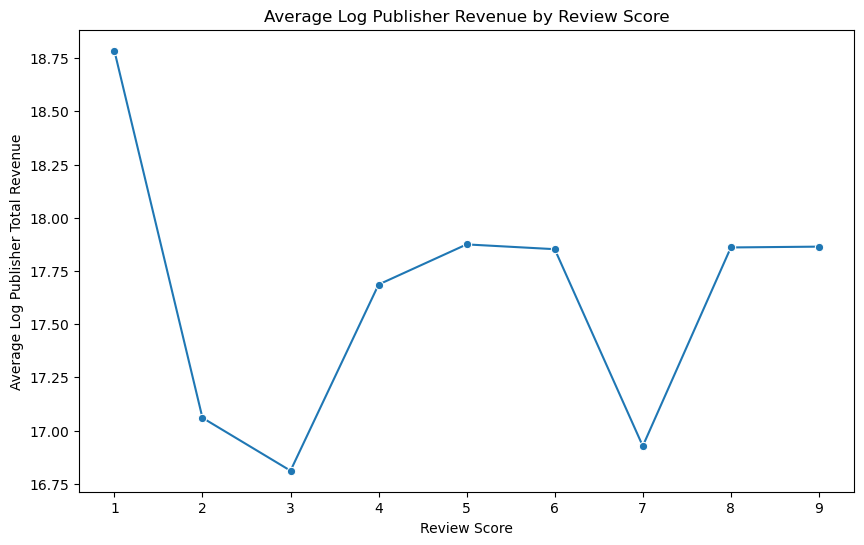

In [41]:
review_score_summary = (
    df_model
    .groupby("review_query_review_score")["log_publisher_total_revenue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=review_score_summary,
    x="review_query_review_score",
    y="log_publisher_total_revenue",
    marker="o"
)

plt.title("Average Log Publisher Revenue by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Log Publisher Total Revenue")

plt.show()

The line graph shows little to no clear upward trend between review score and average log publisher revenue. While a few review-score levels appear slightly higher or lower than others, the pattern is not strong or consistent. This suggests that review score alone is not a strong predictor of publisher-level revenue.

In practical terms, games associated with higher-revenue publishers do not appear to systematically have much higher review scores. Review sentiment may still matter as a basic quality threshold, but it does not seem to explain large differences in publisher revenue on its own.

In [42]:
df_model[df_model["review_query_review_score"] == 1][
    ["steam_id", "store_name", "publisher_name", "publisher_total_revenue"]
].sort_values("publisher_total_revenue", ascending=False)

,steam_id,store_name,publisher_name,publisher_total_revenue
2916,47700,Command & Conquer™ 4 Tiberian Twilight,Electronic Arts,4697048174
3924,2834910,Rocksmith+,Ubisoft,2483883476
3398,1563130,SuperPower 3,THQ Nordic,562496103
1645,201490,Airline Tycoon 2,Kalypso Media Digital,48410902
553,246090,Spacebase DF-9,Double Fine Productions,21514496
2504,1180320,War of the Three Kingdoms,杭州游卡网络技术有限公司,15282738
1646,201510,FlatOut 3: Chaos & Destruction,Strategy First,12233565


Several score-1 games belong to large publishers such as Electronic Arts and Ubisoft. Because publisher revenue is measured at the publisher level rather than the game level, poorly reviewed titles from large publishers can still be associated with very high publisher revenue.

#### 5.2 Review Volume and Publisher Revenue

While review score measures how positively players evaluate a game, total review count captures something different: overall player reach. Games with larger audiences tend to accumulate more reviews simply because more players interact with the game.

Because of this, review volume may serve as a rough proxy for commercial scale. If publisher revenue is more closely related to player reach than to review sentiment alone, we would expect games associated with higher-revenue publishers to have higher review counts on average.

To explore this possibility, the next step summarizes publisher revenue across different levels of review volume.

In [43]:
df_model["log_review_total_reviews"] = np.log1p(df_model["review_query_total_reviews"])

df_model[["review_query_total_reviews", "log_review_total_reviews"]].head()

,review_query_total_reviews,log_review_total_reviews
0,257742,12.459718
1,9049,9.110520
2,7257,8.889860
3,3248,8.086103
4,27552,10.223867


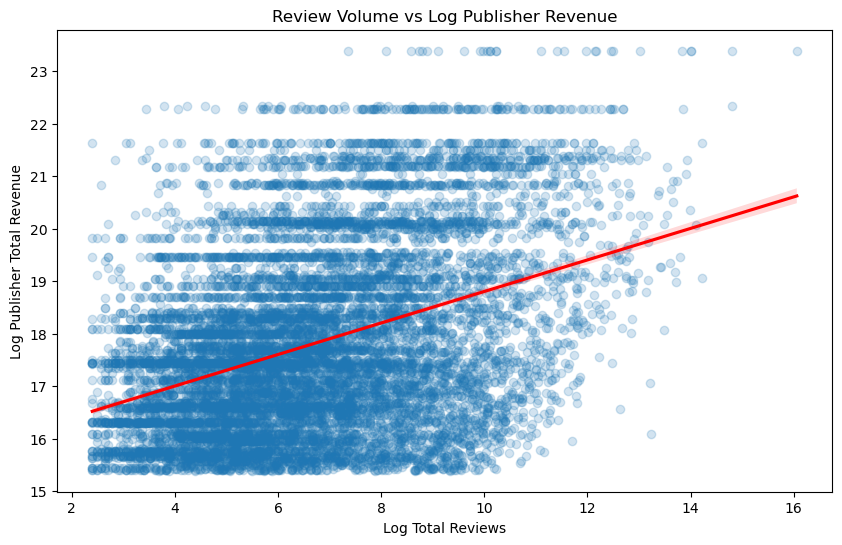

In [44]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_model,
    x="log_review_total_reviews",
    y="log_publisher_total_revenue",
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Review Volume vs Log Publisher Revenue")
plt.xlabel("Log Total Reviews")
plt.ylabel("Log Publisher Total Revenue")

plt.show()

The fitted line shows a clearer positive relationship between review volume and publisher revenue than the earlier review-score comparison. Although the data remain noisy, games with larger review counts are more likely to be associated with higher-revenue publishers.

This suggests that review volume, which reflects player reach, is more closely tied to publisher-level commercial scale than review sentiment alone.

To complement the plot, the table below summarizes average publisher revenue across quartiles of review volume. This makes it easier to see whether games with larger review counts are systematically associated with higher-revenue publishers.

In [45]:
df_model["review_volume_quartile"] = pd.qcut(
    df_model["log_review_total_reviews"],
    q=4,
    labels=["Q1 Lowest", "Q2", "Q3", "Q4 Highest"]
)

review_volume_quartile_summary = (
    df_model
    .groupby("review_volume_quartile")
    .agg(
        avg_log_publisher_revenue=("log_publisher_total_revenue", "mean"),
        median_log_publisher_revenue=("log_publisher_total_revenue", "median"),
        game_count=("steam_id", "count")
    )
    .reset_index()
)

review_volume_quartile_summary

,review_volume_quartile,avg_log_publisher_revenue,median_log_publisher_revenue,game_count
0,Q1 Lowest,17.049366,16.728220,2875
1,Q2,17.517493,17.360293,2849
2,Q3,18.027051,17.722943,2860
3,Q4 Highest,18.672068,18.547798,2862


To further investigate the relationship between review volume and publisher scale, it is useful to look at catalog concentration. Do top publishers rely on a single massive hit, or do they have multiple high-volume titles? 

This query uses a SQL window function (`ROW_NUMBER()`) to partition the dataset by publisher and rank their games by total review volume. Filtering for the top-ranked game per publisher reveals the "biggest hit" driving their reach.

In [46]:
query = """
WITH RankedPublisherGames AS (
    SELECT 
        p.publisher_name,
        p.publisher_tier,
        s.store_name,
        s.review_query_total_reviews,
        ROW_NUMBER() OVER (PARTITION BY p.publisher_name ORDER BY s.review_query_total_reviews DESC) AS catalog_rank
    FROM publisher_games AS p
    INNER JOIN steam_store AS s ON p.steam_id = s.steam_id
    WHERE s.review_query_total_reviews IS NOT NULL
)
SELECT 
    publisher_name,
    publisher_tier,
    store_name AS top_game_by_volume,
    review_query_total_reviews AS top_game_reviews
FROM RankedPublisherGames
WHERE catalog_rank = 1
ORDER BY top_game_reviews DESC
LIMIT 15;
"""
df_top_hits = pd.read_sql_query(query, connection)
df_top_hits

,publisher_name,publisher_tier,top_game_by_volume,top_game_reviews
0,Valve,High Revenue,Counter-Strike 2,9429226
1,"KRAFTON, Inc.",High Revenue,PUBG: BATTLEGROUNDS,2681107
2,Re-Logic,High Revenue,Terraria,1502712
3,Ubisoft,High Revenue,Tom Clancy's Rainbow Six Siege,1486663
4,Facepunch Studios,High Revenue,Rust,1334715
5,Game Science,High Revenue,Black Myth: Wukong,1194321
6,Bandai Namco Entertainment,High Revenue,ELDEN RING,1117816
7,PlayStation Publishing LLC,High Revenue,HELLDIVERS™ 2,1110017
8,Electronic Arts,High Revenue,Apex Legends™,1033852
9,ConcernedApe,High Revenue,Stardew Valley,982149


#### 5.3 Player Engagement and Commercial Outcomes

Review sentiment and review volume both capture aspects of player feedback, but they do not directly measure how actively players engage with a game after acquiring it.

To explore whether engagement intensity is related to publisher revenue, games are grouped into engagement buckets based on the stickiness measure created earlier. Stickiness reflects the share of owners who are actively playing at a given moment, which provides a rough proxy for player engagement.

If engagement is related to commercial success, games with higher engagement levels should be associated with publishers that generate higher total revenue on average.

In [47]:
query = """
SELECT
    p.steam_id,
    p.publisher_tier,
    p.publisher_total_revenue,
    spy.stickiness_pct
FROM publisher_games AS p
INNER JOIN steamspy AS spy
ON p.steam_id = spy.appid
WHERE spy.stickiness_pct IS NOT NULL
AND spy.stickiness_pct > 0
AND p.publisher_total_revenue IS NOT NULL
"""
engagement_tier_df = pd.read_sql_query(query, connection)

engagement_tier_df["log_publisher_total_revenue"] = np.log1p(
    engagement_tier_df["publisher_total_revenue"]
)

engagement_tier_df.head(3)

,steam_id,publisher_tier,publisher_total_revenue,stickiness_pct,log_publisher_total_revenue
0,730,High Revenue,14358384339,0.675957,23.387600
1,1172470,High Revenue,4697048174,0.082841,22.270200
2,578080,High Revenue,5020415776,0.209788,22.336779


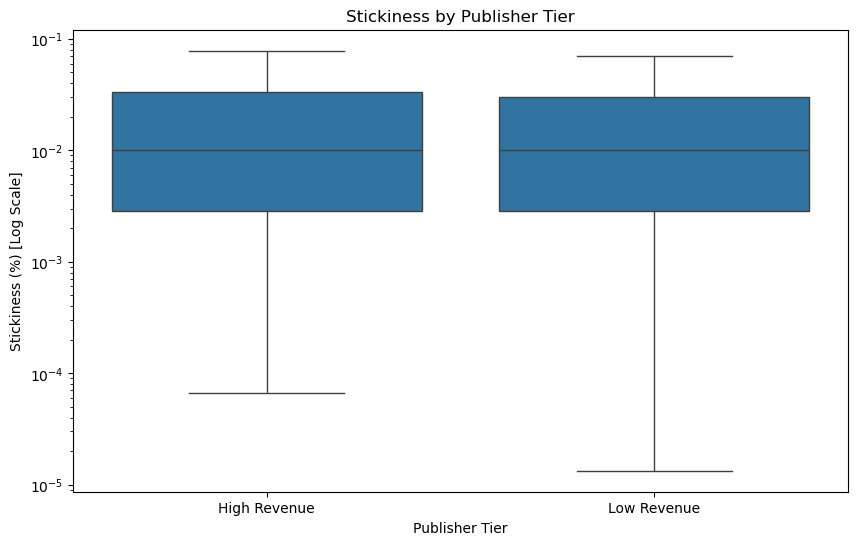

In [48]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=engagement_tier_df,
    x="publisher_tier",
    y="stickiness_pct",
    showfliers=False
)

plt.yscale("log")
plt.title("Stickiness by Publisher Tier")
plt.xlabel("Publisher Tier")
plt.ylabel("Stickiness (%) [Log Scale]")

plt.show()

The boxplot shows substantial overlap in engagement intensity across high-revenue and low-revenue publishers. While there may be some differences in the distribution, stickiness does not appear to cleanly separate the two groups.

This suggests that engagement intensity alone is not a strong standalone explanation for publisher-level revenue differences. Compared with the earlier analysis, review volume appears to provide a clearer signal of commercial scale than engagement does.

The table below summarizes average publisher revenue by broad engagement buckets. This provides a simple grouped view of whether higher stickiness levels are associated with meaningfully higher publisher revenue.

In [49]:
engagement_tier_df["engagement_bucket"] = pd.qcut(
    engagement_tier_df["stickiness_pct"],
    q=4,
    labels=["Q1 Lowest", "Q2", "Q3", "Q4 Highest"]
)

engagement_bucket_summary = (
    engagement_tier_df
    .groupby("engagement_bucket")
    .agg(
        avg_log_publisher_revenue=("log_publisher_total_revenue", "mean"),
        median_log_publisher_revenue=("log_publisher_total_revenue", "median"),
        game_count=("steam_id", "count")
    )
    .reset_index()
)

engagement_bucket_summary

,engagement_bucket,avg_log_publisher_revenue,median_log_publisher_revenue,game_count
0,Q1 Lowest,18.026618,17.741709,1789
1,Q2,18.066950,17.722943,1976
2,Q3,18.167883,17.867675,1467
3,Q4 Highest,18.326722,18.079297,1715


### 6. Regression Comparison of Revenue Predictors

The descriptive analysis in Section 5 suggests that review score alone is not strongly associated with publisher revenue. While review volume appears to show a somewhat clearer relationship with commercial scale, engagement intensity does not appear to be a strong predictor either.

To examine these relationships more systematically, the next step uses simple regression models to compare how well different variables predict publisher revenue. In particular, the analysis compares models based on **review score**, **review volume**, and **player engagement** to evaluate which factors provide the strongest statistical signal of publisher-level commercial outcomes.

### 6.1 Regression Model Setup

The original review score variable is reported on a 0–10 integer scale, which creates only a small number of distinct values and can make visualizations appear artificially discrete. To obtain a more continuous sentiment measure, a review positivity percentage is calculated using the share of positive reviews out of total reviews.

In [50]:
query = """

SELECT
    s.steam_id,
    s.review_query_total_positive,
    s.review_query_total_negative,
    s.review_query_total_reviews,
    spy.stickiness_pct,
    p.publisher_total_revenue
FROM steam_store AS s
INNER JOIN publisher_games AS p
    ON s.steam_id = p.steam_id
LEFT JOIN steamspy AS spy
    ON s.steam_id = spy.appid
WHERE s.review_query_total_reviews IS NOT NULL
AND p.publisher_total_revenue IS NOT NULL

"""

df_reg = pd.read_sql_query(query, connection)

df_reg.head()

,steam_id,review_query_total_positive,review_query_total_negative,review_query_total_reviews,stickiness_pct,publisher_total_revenue
0,10,251093,6649,257742,0.048820,14358384339
1,20,7883,1166,9049,0.004400,14358384339
2,30,6552,705,7257,0.001160,14358384339
3,40,2703,545,3248,0.000093,14358384339
4,50,26264,1288,27552,0.002114,14358384339


In [51]:
df_reg["review_positive_pct"] = (
    df_reg["review_query_total_positive"] /
    (df_reg["review_query_total_positive"] + df_reg["review_query_total_negative"])
) * 100

df_reg.head()

,steam_id,review_query_total_positive,review_query_total_negative,review_query_total_reviews,stickiness_pct,publisher_total_revenue,review_positive_pct
0,10,251093,6649,257742,0.048820,14358384339,97.420289
1,20,7883,1166,9049,0.004400,14358384339,87.114598
2,30,6552,705,7257,0.001160,14358384339,90.285242
3,40,2703,545,3248,0.000093,14358384339,83.220443
4,50,26264,1288,27552,0.002114,14358384339,95.325203


A log transformation is applied to publisher revenue and total review count because both variables are highly skewed. This makes the variables easier to model and interpret by reducing the influence of extremely large values. The regression sample is also restricted to observations with positive stickiness values so that engagement can be included consistently in later comparisons.

In [52]:
df_reg["log_publisher_total_revenue"] = np.log1p(df_reg["publisher_total_revenue"])
df_reg["log_review_total_reviews"] = np.log1p(df_reg["review_query_total_reviews"])

df_reg = df_reg[df_reg["stickiness_pct"] > 0].copy()

df_reg.head()

,steam_id,review_query_total_positive,review_query_total_negative,review_query_total_reviews,stickiness_pct,publisher_total_revenue,review_positive_pct,log_publisher_total_revenue,log_review_total_reviews
0,10,251093,6649,257742,0.048820,14358384339,97.420289,23.3876,12.459718
1,20,7883,1166,9049,0.004400,14358384339,87.114598,23.3876,9.110520
2,30,6552,705,7257,0.001160,14358384339,90.285242,23.3876,8.889860
3,40,2703,545,3248,0.000093,14358384339,83.220443,23.3876,8.086103
4,50,26264,1288,27552,0.002114,14358384339,95.325203,23.3876,10.223867


### 6.2 Model 1: Review Positivity Percentage Only

The first regression model tests whether review sentiment alone helps explain publisher revenue. The dependent variable is the log of publisher total revenue, and the only predictor is the review positivity percentage.

If review sentiment is a strong predictor of publisher-level commercial outcomes, then this model should show a meaningful relationship between the positivity rate and publisher revenue.

In [53]:
X = df_reg[["review_positive_pct"]]
y = df_reg["log_publisher_total_revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print("Coefficient =", model_1.coef_[0])
print("Intercept =", model_1.intercept_)
print("R-squared =", r2_score(y_test, y_pred_1))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred_1)))

X['intercept']= 1 

model_1 = sm.OLS(y, X)
results = model_1.fit()

results.summary()

Coefficient = -0.007576863355720531
Intercept = 18.766162040174745
R-squared = 0.002583545423349709
RMSE = 1.792410385146426


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     log_publisher_total_revenue   R-squared:                       0.003
Model:                                     OLS   Adj. R-squared:                  0.003
Method:                          Least Squares   F-statistic:                     19.74
Date:                         Sun, 08 Mar 2026   Prob (F-statistic):           9.00e-06
Time:                                 23:01:38   Log-Likelihood:                -13958.
No. Observations:                         6930   AIC:                         2.792e+04
Df Residuals:                             6928   BIC:                         2.793e+04
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
review_positive_pct    -0.0076      0.002     -4.443      0.000      -0.011      -0.004
intercept              18.7607      0.141    133.417      0.000      18.485      19.036
==============================================================================
Omnibus:                      489.043   Durbin-Watson:                   1.584
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              414.858
Skew:                           0.523   Prob(JB):                     8.22e-91
Kurtosis:                       2.414   Cond. No.                         532.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

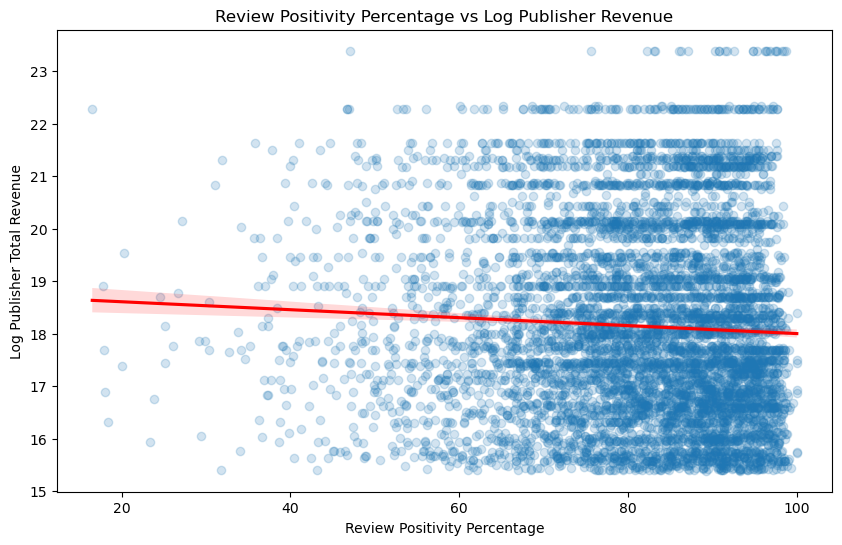

In [54]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_reg,
    x="review_positive_pct",
    y="log_publisher_total_revenue",
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Review Positivity Percentage vs Log Publisher Revenue")
plt.xlabel("Review Positivity Percentage")
plt.ylabel("Log Publisher Total Revenue")

plt.show()

The first model shows that review positivity percentage has very little explanatory power for publisher revenue. The R-squared is very close to zero, which means review sentiment alone explains only a very small share of the variation in log publisher revenue.

The fitted line in the plot is nearly flat, and the coefficient is also very small and slightly negative. Together, these results suggest that review sentiment alone is a weak predictor of publisher-level commercial outcomes.

### 6.2 Model 2: Review Volume Only

The second regression model tests whether review volume is a stronger predictor of publisher revenue than review sentiment alone. The dependent variable remains the log of publisher total revenue, while the predictor is the log of total review count.

Because review volume reflects the size of a game’s player base more directly than review sentiment, it is a plausible proxy for commercial scale. If this variable is more relevant to publisher revenue, the model should show stronger explanatory power than Model 1.

In [55]:
X = df_reg[["log_review_total_reviews"]]
y = df_reg["log_publisher_total_revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_2 = LinearRegression()
model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)

print("Coefficient =", model_2.coef_[0])
print("Intercept =", model_2.intercept_)
print("R-squared =", r2_score(y_test, y_pred_2))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred_2)))

X['intercept']= 1 

model_2 = sm.OLS(y, X)
results = model_2.fit()

results.summary()

Coefficient = 0.3012969071285425
Intercept = 15.842957161948469
R-squared = 0.08630469805945051
RMSE = 1.7155361862130107


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     log_publisher_total_revenue   R-squared:                       0.106
Model:                                     OLS   Adj. R-squared:                  0.106
Method:                          Least Squares   F-statistic:                     820.0
Date:                         Sun, 08 Mar 2026   Prob (F-statistic):          1.53e-170
Time:                                 23:01:38   Log-Likelihood:                -13581.
No. Observations:                         6930   AIC:                         2.717e+04
Df Residuals:                             6928   BIC:                         2.718e+04
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
log_review_total_reviews     0.2932      0.010     28.635      0.000       0.273       0.313
intercept                   15.8992      0.081    196.178      0.000      15.740      16.058
==============================================================================
Omnibus:                      335.075   Durbin-Watson:                   1.651
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              253.573
Skew:                           0.376   Prob(JB):                     8.66e-56
Kurtosis:                       2.440   Cond. No.                         31.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

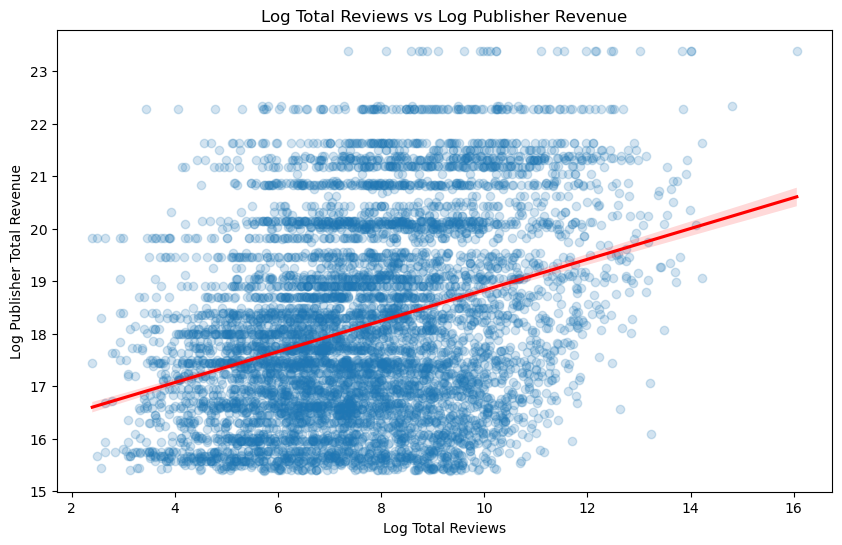

In [56]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_reg,
    x="log_review_total_reviews",
    y="log_publisher_total_revenue",
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Log Total Reviews vs Log Publisher Revenue")
plt.xlabel("Log Total Reviews")
plt.ylabel("Log Publisher Total Revenue")

plt.show()

The second model shows that review volume has more explanatory power than review sentiment alone. The R-squared is still modest, but it is noticeably higher than in Model 1, and the fitted line shows a clearer positive relationship.

The positive coefficient indicates that games with larger review counts are more likely to be associated with higher-revenue publishers. This is consistent with the earlier descriptive analysis, which suggested that review volume is more closely tied to commercial scale than review sentiment.

### 6.3 Model 3: Player Engagement Only

The third regression model tests whether player engagement helps explain publisher revenue. The dependent variable remains the log of publisher total revenue, while the predictor is stickiness, defined earlier as concurrent users divided by estimated owners.

If games that sustain stronger active engagement are more likely to be associated with higher-revenue publishers, then this model should show a clearer relationship than the review-sentiment model.

In [57]:
X = df_reg[["stickiness_pct"]]
y = df_reg["log_publisher_total_revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_3 = LinearRegression()
model_3.fit(X_train, y_train)

y_pred_3 = model_3.predict(X_test)

print("Coefficient =", model_3.coef_[0])
print("Intercept =", model_3.intercept_)
print("R-squared =", r2_score(y_test, y_pred_3))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred_3)))

X['intercept']= 1 

model_3 = sm.OLS(y, X)
results = model_3.fit()

results.summary()

Coefficient = 0.2833002555256944
Intercept = 18.135379284405204
R-squared = -0.0005454997204723533
RMSE = 1.7952197137720802


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     log_publisher_total_revenue   R-squared:                       0.001
Model:                                     OLS   Adj. R-squared:                  0.001
Method:                          Least Squares   F-statistic:                     4.951
Date:                         Sun, 08 Mar 2026   Prob (F-statistic):             0.0261
Time:                                 23:01:39   Log-Likelihood:                -13966.
No. Observations:                         6930   AIC:                         2.794e+04
Df Residuals:                             6928   BIC:                         2.795e+04
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
stickiness_pct     0.2388      0.107      2.225      0.026       0.028       0.449
intercept         18.1318      0.022    808.121      0.000      18.088      18.176
==============================================================================
Omnibus:                      508.496   Durbin-Watson:                   1.586
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              414.784
Skew:                           0.516   Prob(JB):                     8.53e-91
Kurtosis:                       2.390   Cond. No.                         4.93
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

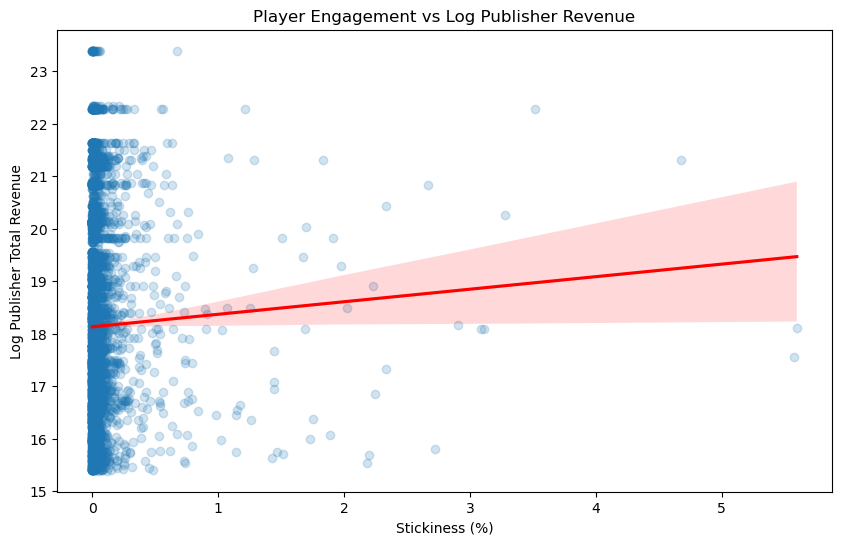

In [58]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_reg,
    x="stickiness_pct",
    y="log_publisher_total_revenue",
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Player Engagement vs Log Publisher Revenue")
plt.xlabel("Stickiness (%)")
plt.ylabel("Log Publisher Total Revenue")

plt.show()

The third model shows that player engagement has almost no explanatory power for publisher revenue. The R-squared is effectively zero and slightly negative, which indicates that this model does not improve meaningfully on a simple baseline prediction.

The fitted line is nearly flat, which is consistent with the earlier descriptive analysis. This suggests that engagement intensity, at least as measured by stickiness in this snapshot, is not a strong predictor of publisher-level revenue.

### 6.4 Comparing Model Performance

The three regression models can now be compared directly using the same two metrics: **R-squared** and **RMSE**. R-squared shows how much variation in publisher revenue is explained by each predictor, while RMSE shows the typical prediction error on the test set.

Comparing these values makes it easier to see which variable provides the strongest statistical signal of publisher-level commercial outcomes.

In [59]:
model_comparison = pd.DataFrame({
    "model": [
        "Model 1: Review Positivity Percentage",
        "Model 2: Review Volume",
        "Model 3: Player Engagement"
    ],
    "r_squared": [
        r2_score(y_test, y_pred_1),
        r2_score(y_test, y_pred_2),
        r2_score(y_test, y_pred_3)
    ],
    "rmse": [
        np.sqrt(mean_squared_error(y_test, y_pred_1)),
        np.sqrt(mean_squared_error(y_test, y_pred_2)),
        np.sqrt(mean_squared_error(y_test, y_pred_3))
    ]
})

model_comparison

,model,r_squared,rmse
0,Model 1: Review Positivity Percentage,0.002584,1.792410
1,Model 2: Review Volume,0.086305,1.715536
2,Model 3: Player Engagement,-0.000545,1.795220


The comparison table shows that **review volume** performs better than the other two predictors. Among the three single-variable models, it has the highest R-squared and the lowest RMSE, which means it explains more variation in publisher revenue and produces somewhat smaller prediction errors.

At the same time, its explanatory power is still limited overall. Even the strongest model explains only a modest share of the variation in publisher revenue. This suggests that publisher-level commercial outcomes are influenced by additional factors beyond review sentiment, review volume, and engagement intensity alone.

Taken together, the regression results support the earlier descriptive analysis. Review sentiment and player engagement are weak standalone predictors of publisher revenue, while review volume appears to be the strongest of the three variables examined here.

### 6.5 Combined Model

The previous models tested each predictor separately. The final model combines **review positivity percentage**, **review volume**, and **player engagement** in a single regression to examine whether review volume still stands out once the other variables are included at the same time.

This combined model does not attempt to explain all sources of publisher revenue, but it provides a more complete comparison of the three variables examined in this section.

In [60]:
X = df_reg[["review_positive_pct", "log_review_total_reviews", "stickiness_pct"]]
y = df_reg["log_publisher_total_revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_4 = LinearRegression()
model_4.fit(X_train, y_train)

y_pred_4 = model_4.predict(X_test)

print("R-squared =", r2_score(y_test, y_pred_4))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred_4)))

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model_4.coef_
})

coef_table

R-squared = 0.10704404599670092
RMSE = 1.6959545364926574


,feature,coefficient
0,review_positive_pct,-0.020087
1,log_review_total_reviews,0.331878
2,stickiness_pct,0.035573


In [61]:
X['intercept']= 1 

model_4 = sm.OLS(y, X)
results = model_4.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     log_publisher_total_revenue   R-squared:                       0.125
Model:                                     OLS   Adj. R-squared:                  0.125
Method:                          Least Squares   F-statistic:                     330.0
Date:                         Sun, 08 Mar 2026   Prob (F-statistic):          2.64e-200
Time:                                 23:01:39   Log-Likelihood:                -13505.
No. Observations:                         6930   AIC:                         2.702e+04
Df Residuals:                             6926   BIC:                         2.705e+04
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
review_positive_pct         -0.0204      0.002    -12.341      0.000      -0.024      -0.017
log_review_total_reviews     0.3253      0.010     31.006      0.000       0.305       0.346
stickiness_pct              -0.0021      0.101     -0.021      0.983      -0.200       0.195
intercept                   17.3115      0.140    123.879      0.000      17.038      17.585
==============================================================================
Omnibus:                      265.782   Durbin-Watson:                   1.644
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              225.045
Skew:                           0.371   Prob(JB):                     1.36e-49
Kurtosis:                       2.523   Cond. No.                         567.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The combined model performs somewhat better than the three single-variable models, with an R-squared of 0.107 and an RMSE of 1.696. This means that the model explains about 10.7% of the variation in log publisher revenue, which is still limited overall but represents an improvement over the earlier regressions.

Among the three predictors, log total review count appears to contribute the strongest positive relationship with publisher revenue. In contrast, review positivity percentage remains weak and slightly negative, while stickiness contributes very little.

These results reinforce the earlier descriptive analysis. Measures related to **player reach and audience size** appear to be more closely associated with publisher-level commercial outcomes than measures of review sentiment or snapshot engagement alone.

While the combined model improves predictive performance slightly, its explanatory power remains limited overall. This suggests that other factors—such as marketing reach, franchise strength, genre, and platform visibility—likely play a larger role in determining publisher revenue than the variables examined here.

### 7. Conclusion

#### 7.1 Main Finding

This project examined whether player review sentiment is associated with publisher-level commercial success in the Steam ecosystem. The target audience for this analysis is game publishers, product managers, and strategy teams trying to understand which game-level signals are most informative for publisher-level commercial outcomes on Steam.

Using data from Steam Store, SteamSpy, IGDB, and Gamealytic, the analysis linked game-level review information with publisher revenue estimates.

The baseline analysis showed that review sentiment is distributed very similarly across both high-revenue and low-revenue publishers. This suggests that commercially successful publishers do not simply succeed because they made their players happier.

#### 7.2 Regression Results and Interpretation

The regression analysis reinforces this finding. Review positivity percentage alone explains almost none of the variation in publisher revenue, while player engagement also shows very little predictive power in isolation. Among the variables examined, review volume performs noticeably better, suggesting that variables related to player reach and audience size are more closely associated with publisher-level commercial outcomes than review sentiment itself.

Even in the combined model that includes review sentiment, review volume, and engagement together, the explanatory power remains modest. The model explains roughly 10% of the variation in publisher revenue, which suggests that many other factors likely drive commercial outcomes on the Steam platform.

These results imply that commercial success on Steam is likely influenced more strongly by factors such as marketing reach, franchise recognition, platform visibility, and distribution networks than by review sentiment alone. Review sentiment may still matter as a quality signal or retention factor, but it does not appear to explain large differences in publisher revenue by itself.

#### 7.3 Future Work

Future research could expand this analysis by incorporating additional datasets that better capture visibility and market reach. For example, wishlist counts, marketing spend, genre classifications, and storefront promotion data could help explain why some games achieve much larger audiences than others.

In addition, a longer-run engagement dataset would improve the analysis. The current stickiness measure is based on a single snapshot of concurrent users, which may not fully capture long-term retention. Time-series data on player activity would allow for a more complete analysis of how engagement relates to commercial success over time.

For publishers and product teams, the main implication of this project is that review sentiment alone should not be treated as the primary signal of commercial potential. Among the variables examined here, audience reach appears more informative than sentiment when explaining publisher-level revenue outcomes.